# Selected Cycle Run Diagnostics

This notebook inspects one `sync-check` run and separates three failure modes:

- trigger/cycle selection problems
- accumulation-window timing problems
- PNG display-scaling problems

The default run is `runs/camera/laser_selected_cycle_40px_dot123-sync-check`.

In [10]:
from pathlib import Path
import os
import csv
import json
import math
import statistics

import numpy as np
from PIL import Image, ImageDraw

try:
    import matplotlib.pyplot as plt
except Exception as exc:
    plt = None
    print(f"matplotlib unavailable: {exc}")

try:
    from IPython.display import display
except Exception:
    display = None

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "dmdcontrol").exists() and (PROJECT_ROOT.parent / "dmdcontrol").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DEFAULT_RUN_DIR = PROJECT_ROOT / "runs" / "camera" / "laser_selected_cycle_40px_dot123-sync-check"
RUN_DIR = Path(os.environ.get("DMD_SYNC_RUN_DIR", DEFAULT_RUN_DIR)).expanduser()
if not RUN_DIR.is_absolute():
    RUN_DIR = PROJECT_ROOT / RUN_DIR
OUT_DIR = RUN_DIR / "analysis_outputs"
OUT_DIR.mkdir(exist_ok=True)

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"RUN_DIR      = {RUN_DIR}")
print(f"OUT_DIR      = {OUT_DIR}")
assert RUN_DIR.exists(), RUN_DIR

PROJECT_ROOT = C:\dev\dmdcontrol
RUN_DIR      = C:\dev\dmdcontrol\runs\camera\laser_selected_cycle_40px_dot123-sync-check
OUT_DIR      = C:\dev\dmdcontrol\runs\camera\laser_selected_cycle_40px_dot123-sync-check\analysis_outputs


In [11]:
def load_json(name):
    with (RUN_DIR / name).open("r", encoding="utf-8") as handle:
        return json.load(handle)

metadata = load_json("metadata.json")
summary = load_json("summary.json")
accumulated = np.load(RUN_DIR / "accumulated.npy")
events_npz = np.load(RUN_DIR / "filtered_events.npz")

with (RUN_DIR / "triggers.csv").open("r", newline="", encoding="utf-8") as handle:
    triggers = list(csv.DictReader(handle))
trigger_ts = np.array([int(row["timestamp"]) for row in triggers], dtype=np.int64)
trigger_order = np.argsort(trigger_ts, kind="stable")
ordered_trigger_ts = trigger_ts[trigger_order]

number_sequence = metadata.get("number_sequence") or [1, 2, 3, 4, 5]
cycle_info = summary.get("trigger_cycle_limit") or summary.get("trigger_cycle_selection") or {}
cycle_len = int(cycle_info.get("cycle_length") or len(number_sequence))
selected_cycle_indices = cycle_info.get("selected_cycle_indices") or []
window_us = int(metadata.get("accumulation_window_us") or summary.get("accumulation_window_us") or metadata.get("numbers_exposure_us") or 1500)
resolution = tuple(summary.get("resolution") or metadata.get("resolution") or (accumulated.shape[2], accumulated.shape[1]))

print(f"accumulated shape: {accumulated.shape}, dtype={accumulated.dtype}, min={accumulated.min()}, max={accumulated.max()}")
print(f"events keys: {list(events_npz.keys())}")
print(f"event count: {len(events_npz['t']):,}")
print(f"selected triggers: {len(trigger_ts)}")
print(f"triggers.csv already timestamp-sorted: {bool(np.all(trigger_order == np.arange(len(trigger_order))))}")
print(f"cycle_len: {cycle_len}; selected_cycle_indices: {selected_cycle_indices}")
print(f"window_us: {window_us}; resolution: {resolution}")

accumulated shape: (50, 240, 320), dtype=float32, min=-3.0, max=3.0
events keys: ['x', 'y', 't', 'p']
event count: 564,149
selected triggers: 50
triggers.csv already timestamp-sorted: True
cycle_len: 5; selected_cycle_indices: [9, 10, 11, 12, 13, 14, 15, 16, 18, 19]
window_us: 1500; resolution: (320, 240)


## Run facts

Check this first. New runs select the first complete trigger cycles after the pre-capture flush. Older runs may still contain legacy cycle-selection metadata.

In [12]:
for key in [
    "test", "test_b", "number_size_px", "b_dot_radius", "numbers_exposure_us",
    "dark_time_us", "runtime_seconds", "polarity_mode", "event_noise_filter",
    "accumulation_cycles", "accumulation_start_offset_us",
]:
    print(f"metadata[{key!r}] = {metadata.get(key)}")

print("\nsummary counts")
for key in [
    "raw_rising_trigger_count", "aligned_rising_trigger_count",
    "selected_rising_trigger_count", "actual_trigger_count", "event_count",
]:
    print(f"summary[{key!r}] = {summary.get(key)}")

print("\ntrigger_cycle_limit")
for key, value in cycle_info.items():
    if key == "cycle_event_counts":
        print(f"{key}: {len(value)} counts; first 20 = {value[:20]}")
    else:
        print(f"{key}: {value}")

metadata['test'] = a-numbers-b-static
metadata['test_b'] = None
metadata['number_size_px'] = 400
metadata['b_dot_radius'] = 40
metadata['numbers_exposure_us'] = 1500
metadata['dark_time_us'] = 250
metadata['runtime_seconds'] = None
metadata['polarity_mode'] = signed
metadata['event_noise_filter'] = {'algorithm': 'none', 'delta_t_us': 50000, 'enabled': False, 'filtered_events': 564149, 'filtered_off': 240449, 'filtered_on': 323700, 'kept_fraction': 1.0, 'note': 'Event noise filtering disabled. Local-support parameters are resolved but were not applied.', 'polarity': 'same', 'raw_events': 564149, 'raw_off': 240449, 'raw_on': 323700, 'threshold': 2, 'window_px': 3}
metadata['accumulation_cycles'] = 10
metadata['cycle_selection'] = strongest
metadata['trigger_cluster_us'] = 250

summary counts
summary['raw_rising_trigger_count'] = 5666
summary['aligned_rising_trigger_count'] = 5662
summary['clustered_rising_trigger_count'] = 2831
summary['selected_rising_trigger_count'] = 50
summary['actua

## Trigger timing by 1..5 group

Each group below is one displayed `1,2,3,4,5` set in the selected artifacts. Large `gap_to_next_us` values mean `strongest` skipped physical cycles between selected groups.

In [13]:
event_counts = summary.get("events_per_accumulation_window") or [None] * len(trigger_ts)
dt = np.diff(trigger_ts) if len(trigger_ts) > 1 else np.array([], dtype=np.int64)
inner_dt = []
for group_start in range(0, len(trigger_ts), cycle_len):
    group = trigger_ts[group_start:group_start + cycle_len]
    if len(group) > 1:
        inner_dt.extend(np.diff(group).tolist())
typical_dt = int(statistics.median(inner_dt)) if inner_dt else None
print(f"typical inner trigger dt: {typical_dt} us")
print(f"all selected-trigger dt: min={dt.min() if len(dt) else None}, max={dt.max() if len(dt) else None}, mean={dt.mean() if len(dt) else None}")

for row, group_start in enumerate(range(0, len(trigger_ts), cycle_len), start=1):
    group = trigger_ts[group_start:group_start + cycle_len]
    counts = event_counts[group_start:group_start + cycle_len]
    physical_cycle = selected_cycle_indices[row - 1] if row - 1 < len(selected_cycle_indices) else None
    group_inner_dt = np.diff(group).tolist() if len(group) > 1 else []
    next_index = group_start + cycle_len
    gap_to_next = int(trigger_ts[next_index] - group[-1]) if next_index < len(trigger_ts) else None
    skipped_hint = ""
    if typical_dt and gap_to_next and gap_to_next > 2 * typical_dt:
        skipped_hint = "  <-- skipped physical cycle(s)"
    print(
        f"row {row:02d}: physical_cycle={physical_cycle}, "
        f"start={int(group[0])}, inner_dt={group_inner_dt}, "
        f"gap_to_next_us={gap_to_next}, events={counts}{skipped_hint}"
    )

typical inner trigger dt: 1750 us
all selected-trigger dt: min=1721, max=10471, mean=1927.1020408163265
row 01: physical_cycle=9, start=1780606395564537, inner_dt=[1750, 1750, 1750, 1750], gap_to_next_us=1750, events=[416, 407, 402, 469, 363]
row 02: physical_cycle=10, start=1780606395573287, inner_dt=[1750, 1721, 1750, 1750], gap_to_next_us=1750, events=[465, 433, 477, 490, 280]
row 03: physical_cycle=11, start=1780606395582008, inner_dt=[1750, 1750, 1750, 1751], gap_to_next_us=1750, events=[434, 515, 423, 445, 307]
row 04: physical_cycle=12, start=1780606395590759, inner_dt=[1750, 1756, 1750, 1750], gap_to_next_us=1750, events=[468, 493, 393, 445, 323]
row 05: physical_cycle=13, start=1780606395599515, inner_dt=[1750, 1750, 1750, 1750], gap_to_next_us=1750, events=[467, 412, 426, 486, 295]
row 06: physical_cycle=14, start=1780606395608265, inner_dt=[1722, 1750, 1750, 1750], gap_to_next_us=1750, events=[406, 518, 398, 435, 345]
row 07: physical_cycle=15, start=1780606395616987, inner_

## Saved PNG scaling check

`accumulated.npy` has a true zero background. The existing `accumulated_###.png` files are min/max-normalized per frame. With `--polarity-mode signed`, zero can map to gray instead of black, and that gray jumps frame to frame.

In [14]:
print("idx  frame_min frame_max  saved_min saved_max  saved_zero_bg_median  saved_zero_bg_unique_head")
for i in range(min(15, accumulated.shape[0])):
    png_path = RUN_DIR / f"accumulated_{i + 1:03d}.png"
    saved = np.array(Image.open(png_path))
    zero_mask = accumulated[i] == 0
    bg = saved[zero_mask]
    unique_head = np.unique(bg)[:8].tolist() if bg.size else []
    print(
        f"{i + 1:03d}  {accumulated[i].min():8.1f} {accumulated[i].max():8.1f}"
        f"  {saved.min():9d} {saved.max():9d}  {float(np.median(bg)) if bg.size else math.nan:20.1f}  {unique_head}"
    )

idx  frame_min frame_max  saved_min saved_max  saved_zero_bg_median  saved_zero_bg_unique_head
001      -2.0      1.0          0       255                 170.0  [170]
002      -2.0      2.0          0       255                 127.0  [127]
003      -2.0      3.0          0       255                 102.0  [102]
004      -1.0      2.0          0       255                  85.0  [85]
005      -2.0      2.0          0       255                 127.0  [127]
006      -2.0      2.0          0       255                 127.0  [127]
007      -1.0      2.0          0       255                  85.0  [85]
008      -1.0      2.0          0       255                  85.0  [85]
009      -1.0      2.0          0       255                  85.0  [85]
010      -1.0      1.0          0       255                 127.0  [127]
011      -2.0      2.0          0       255                 127.0  [127]
012      -1.0      1.0          0       255                 127.0  [127]
013      -1.0      1.0          0

## Black-background renderers

These render from `accumulated.npy`, not from the saved PNGs.

- `positive`: show ON events only, zero background stays black.
- `absolute`: show ON and OFF event magnitude, zero background stays black.
- `signed_rgb`: positive is green, negative is magenta, zero background stays black.

Timestamp order from triggers.csv:
  T01 +0.000ms | T02 +1.750ms | T03 +3.500ms | T04 +5.250ms | T05 +7.000ms
  T06 +8.750ms | T07 +10.500ms | T08 +12.221ms | T09 +13.971ms | T10 +15.721ms
  T11 +17.471ms | T12 +19.221ms | T13 +20.971ms | T14 +22.721ms | T15 +24.472ms
  T16 +26.222ms | T17 +27.972ms | T18 +29.728ms | T19 +31.478ms | T20 +33.228ms
  T21 +34.978ms | T22 +36.728ms | T23 +38.478ms | T24 +40.228ms | T25 +41.978ms
  T26 +43.728ms | T27 +45.450ms | T28 +47.200ms | T29 +48.950ms | T30 +50.700ms
  T31 +52.450ms | T32 +54.200ms | T33 +55.950ms | T34 +57.700ms | T35 +59.450ms
  T36 +61.200ms | T37 +62.956ms | T38 +64.706ms | T39 +66.456ms | T40 +68.207ms
  T41 +78.678ms | T42 +80.428ms | T43 +82.178ms | T44 +83.928ms | T45 +85.678ms
  T46 +87.428ms | T47 +89.178ms | T48 +90.928ms | T49 +92.678ms | T50 +94.428ms
C:\dev\dmdcontrol\runs\camera\laser_selected_cycle_40px_dot123-sync-check\analysis_outputs\timestamp_ordered_positive_black_background_gamma.png


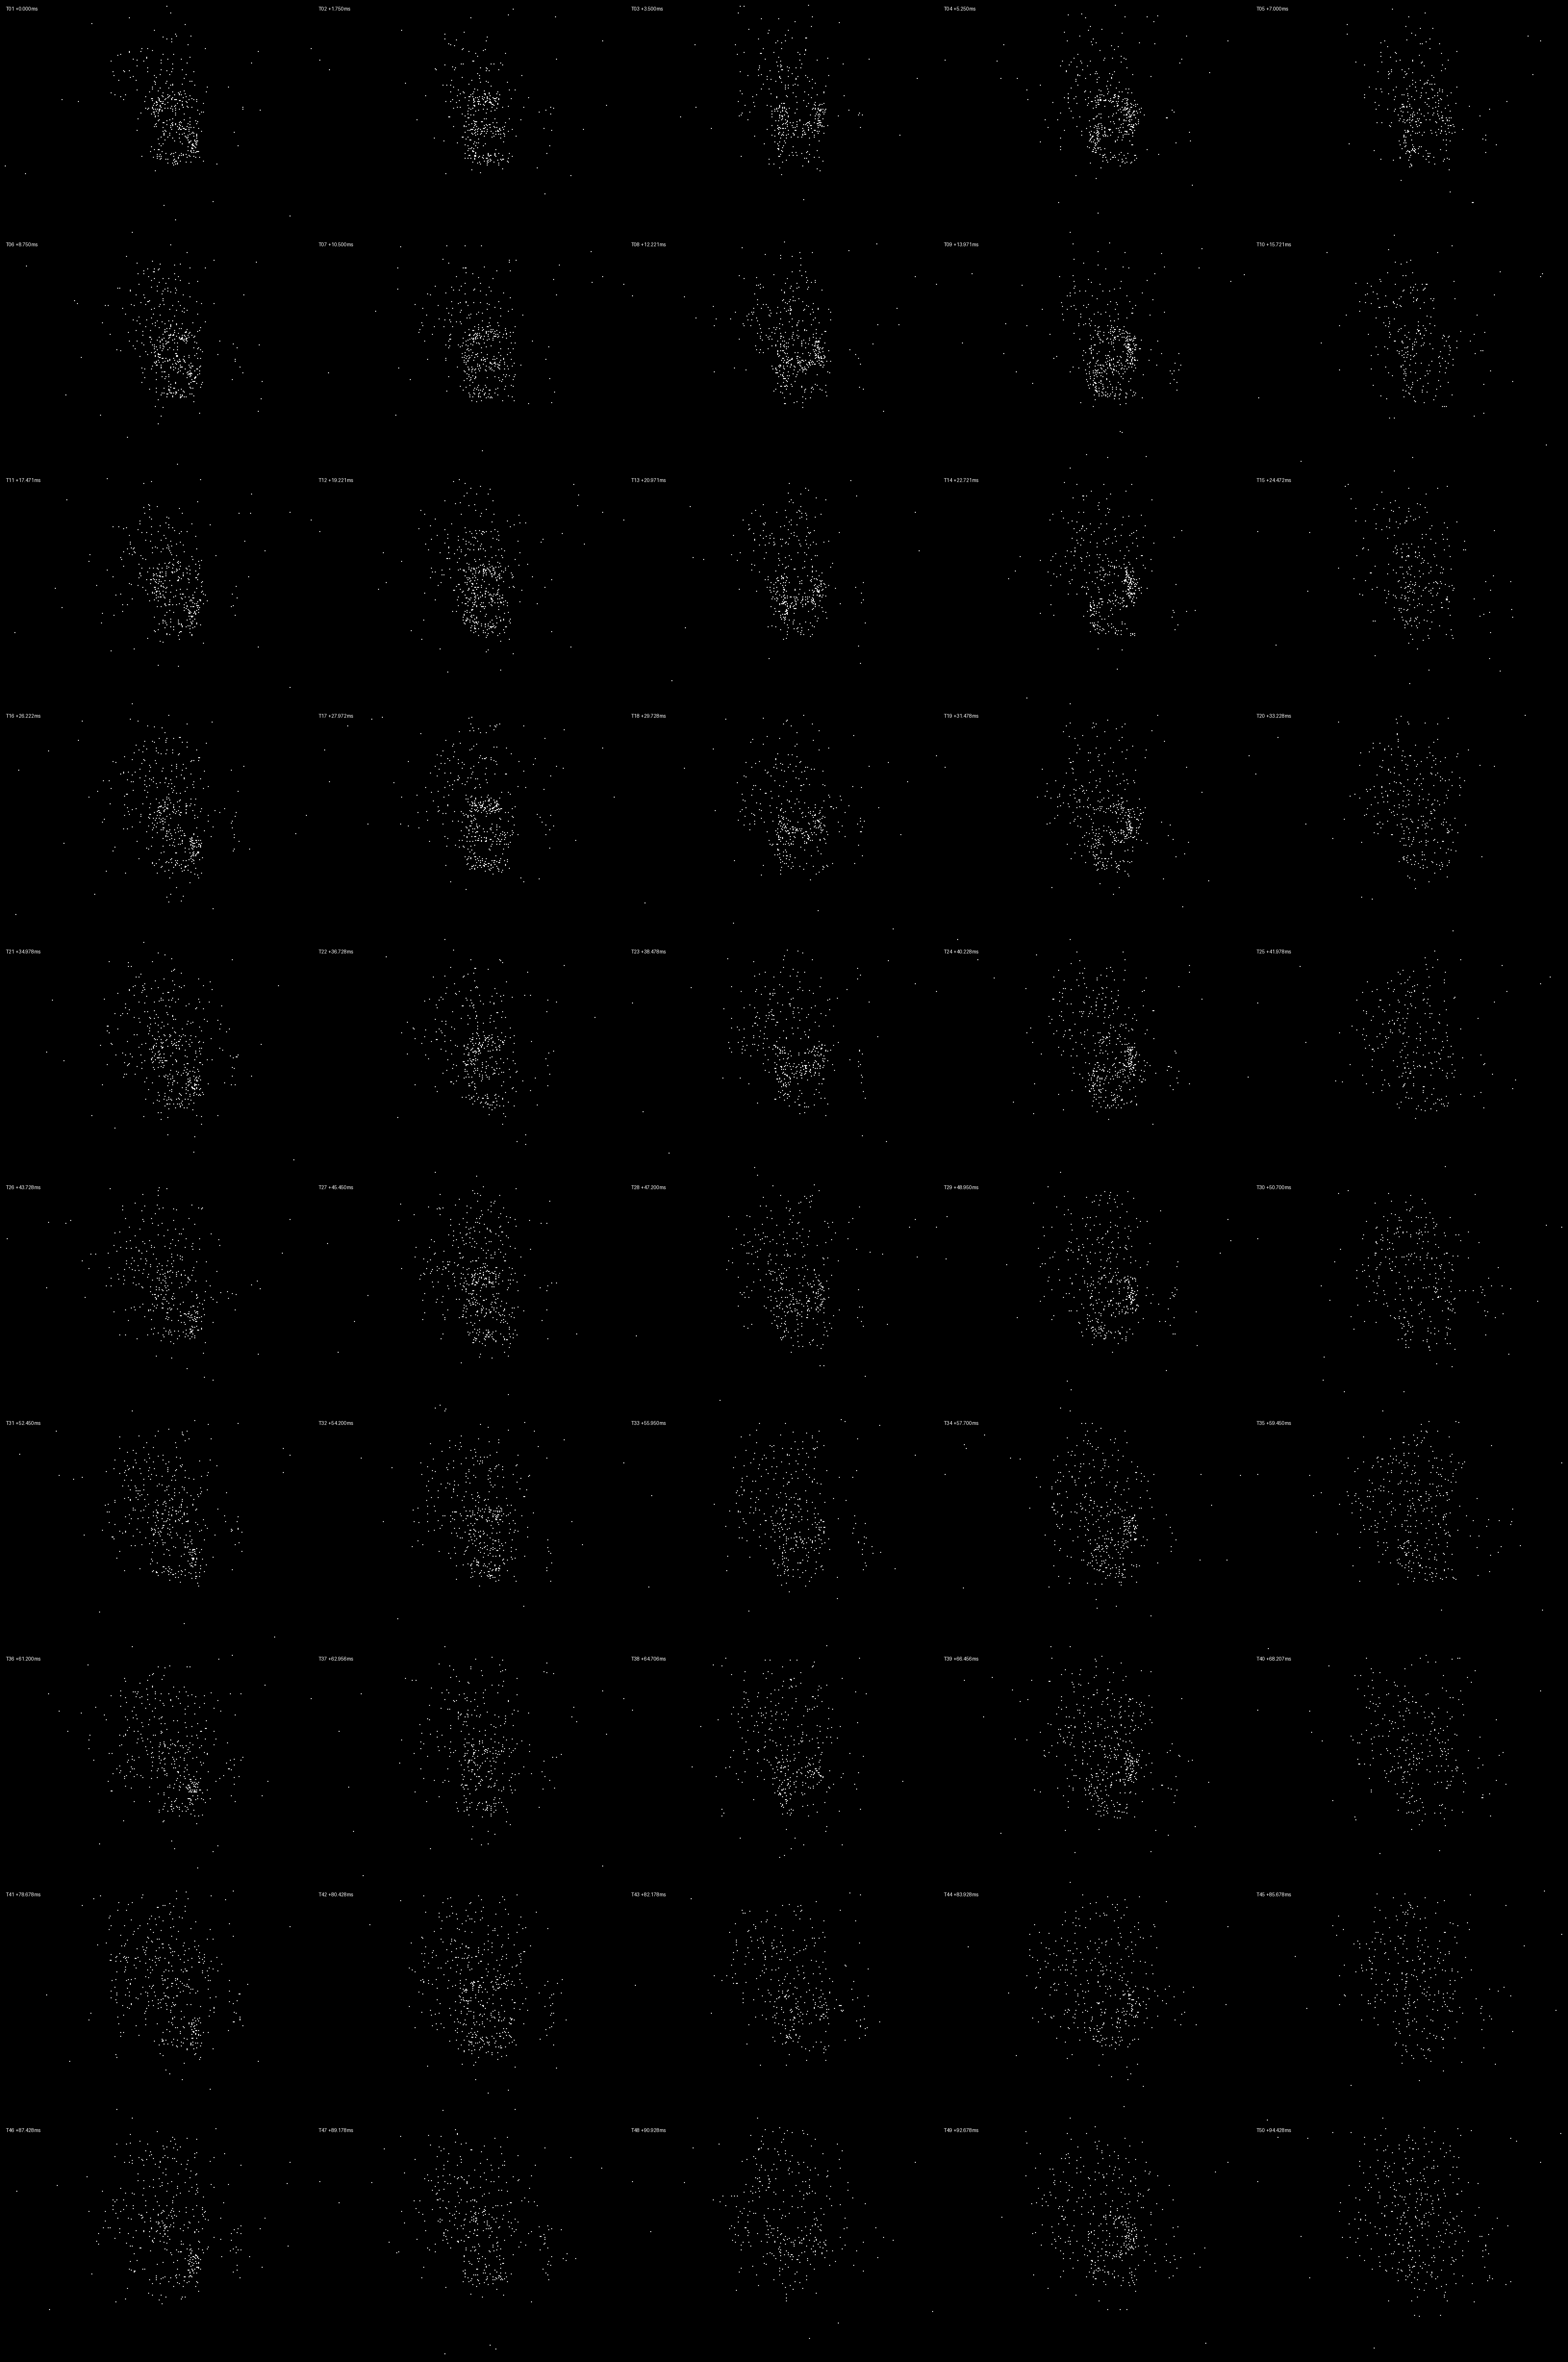

C:\dev\dmdcontrol\runs\camera\laser_selected_cycle_40px_dot123-sync-check\analysis_outputs\timestamp_ordered_absolute_black_background_gamma.png


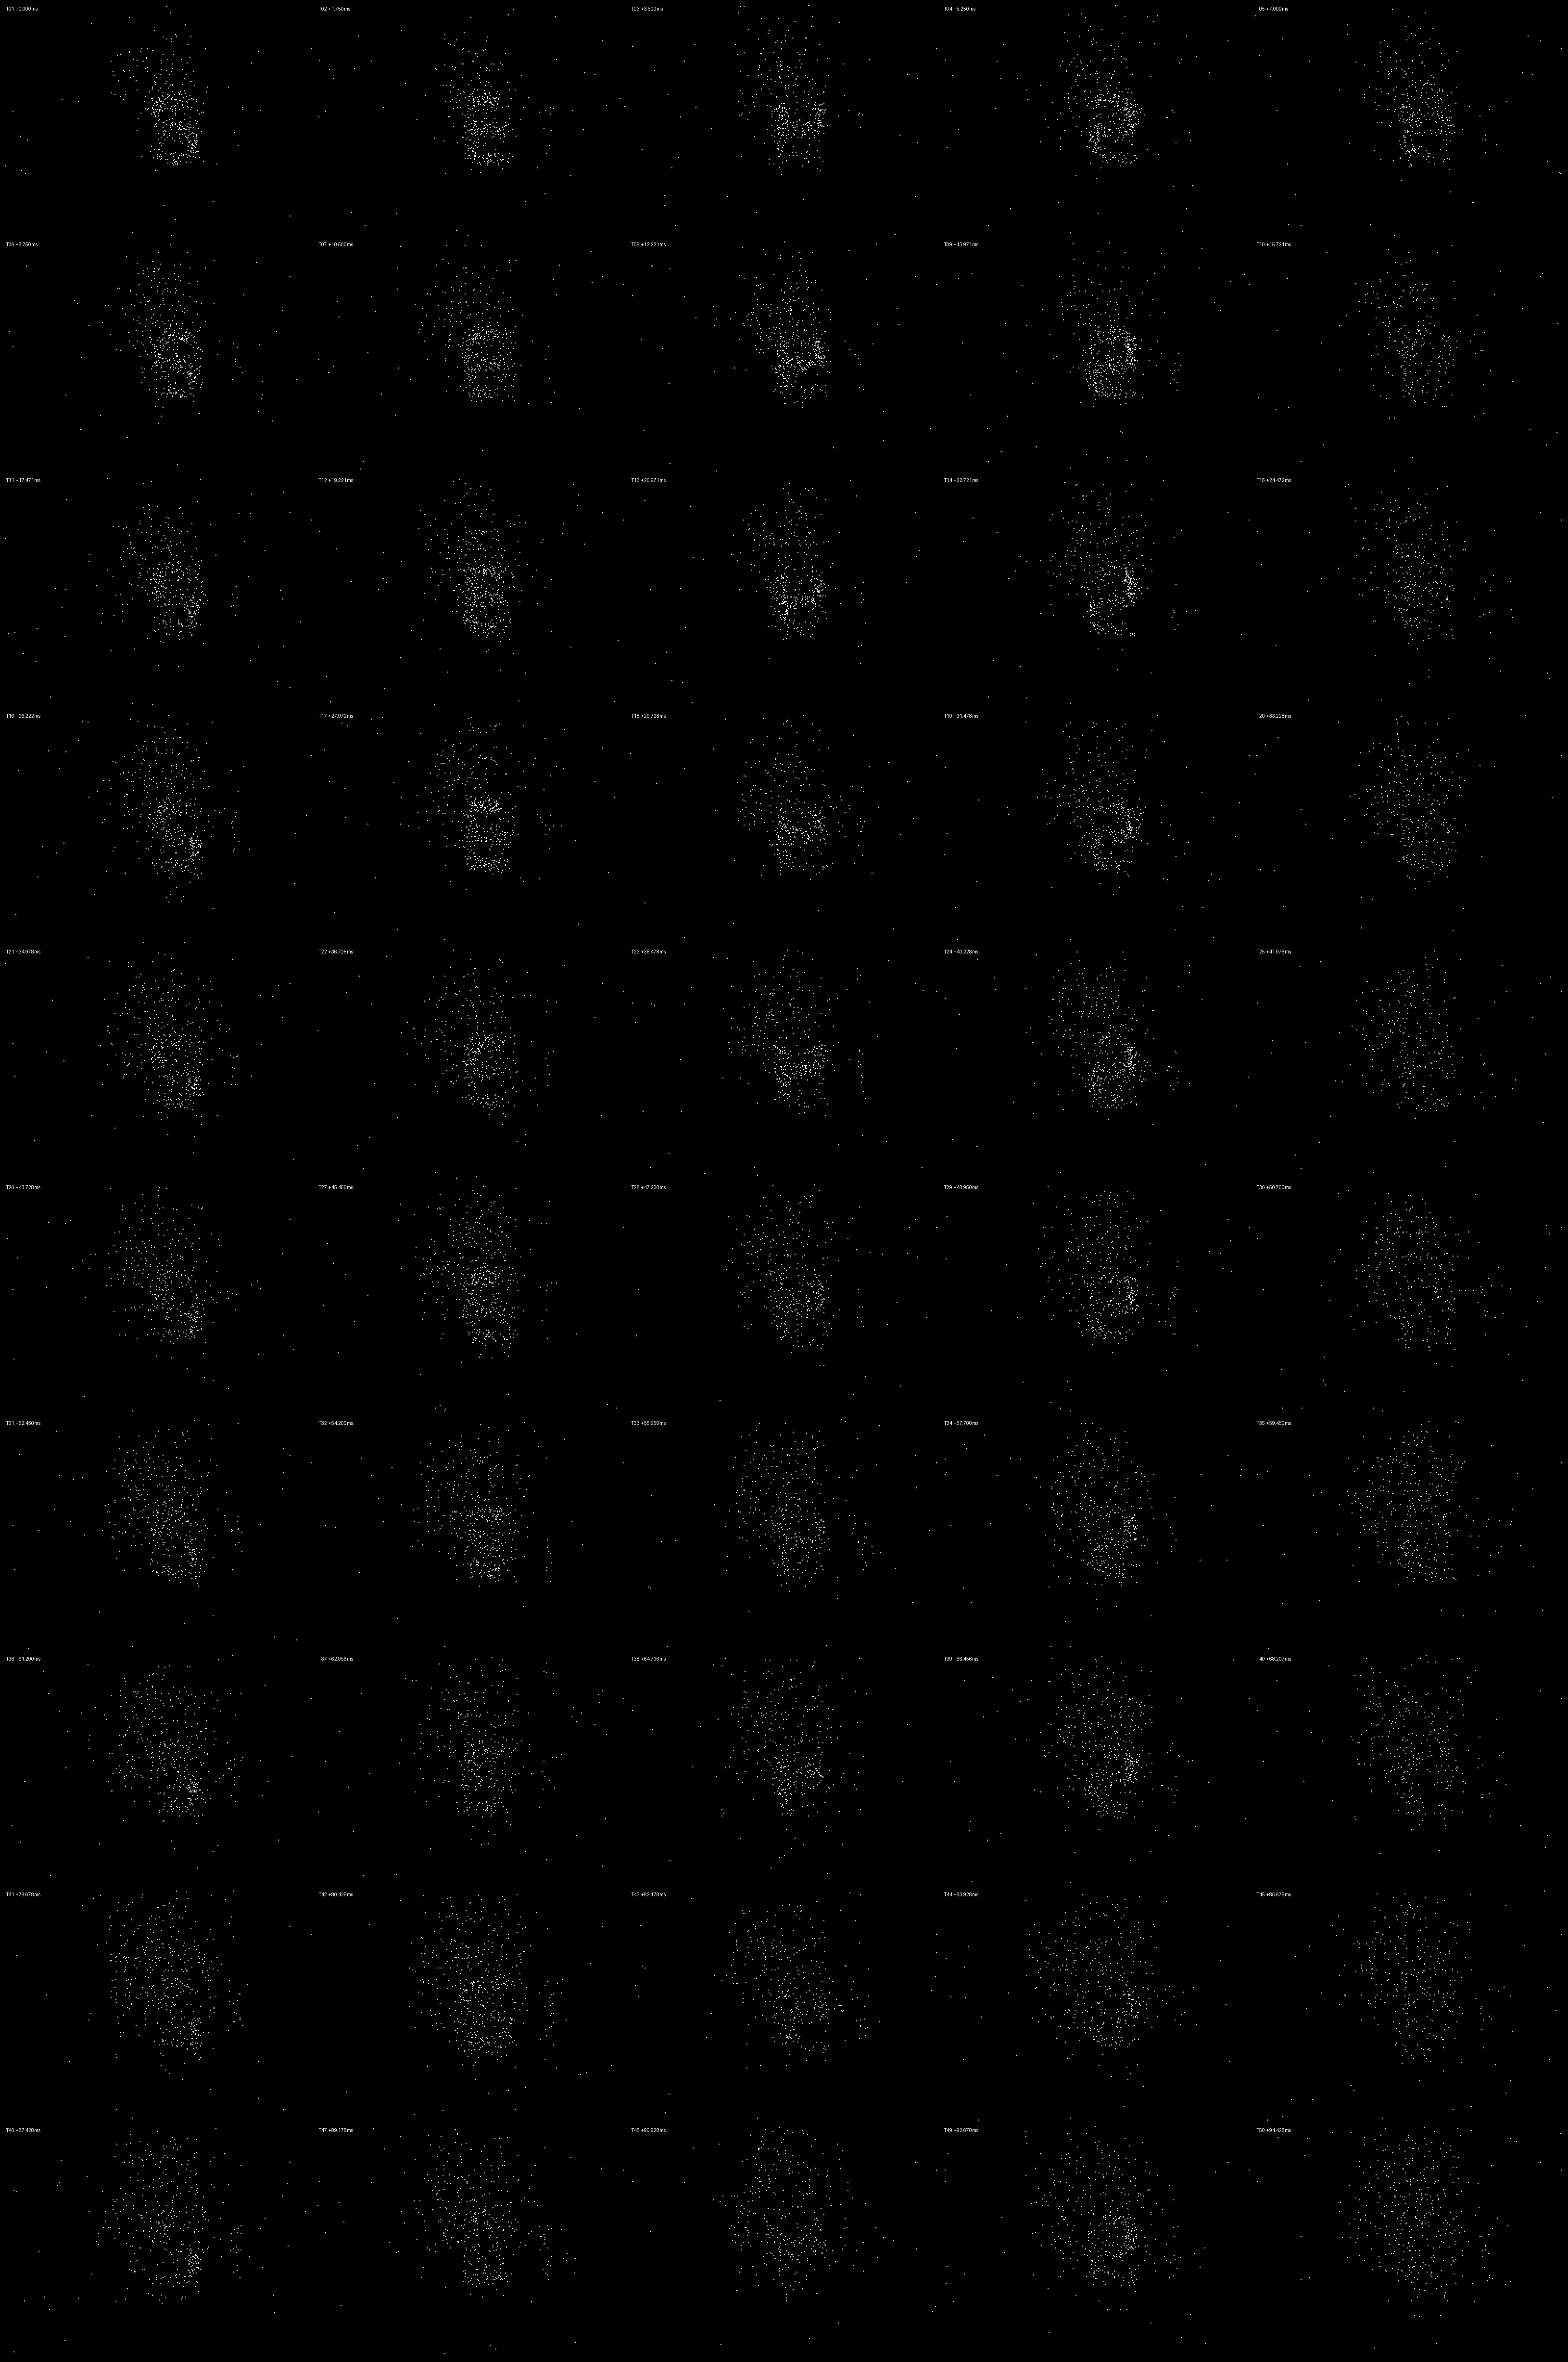

C:\dev\dmdcontrol\runs\camera\laser_selected_cycle_40px_dot123-sync-check\analysis_outputs\timestamp_ordered_signed_rgb_black_background_gamma.png


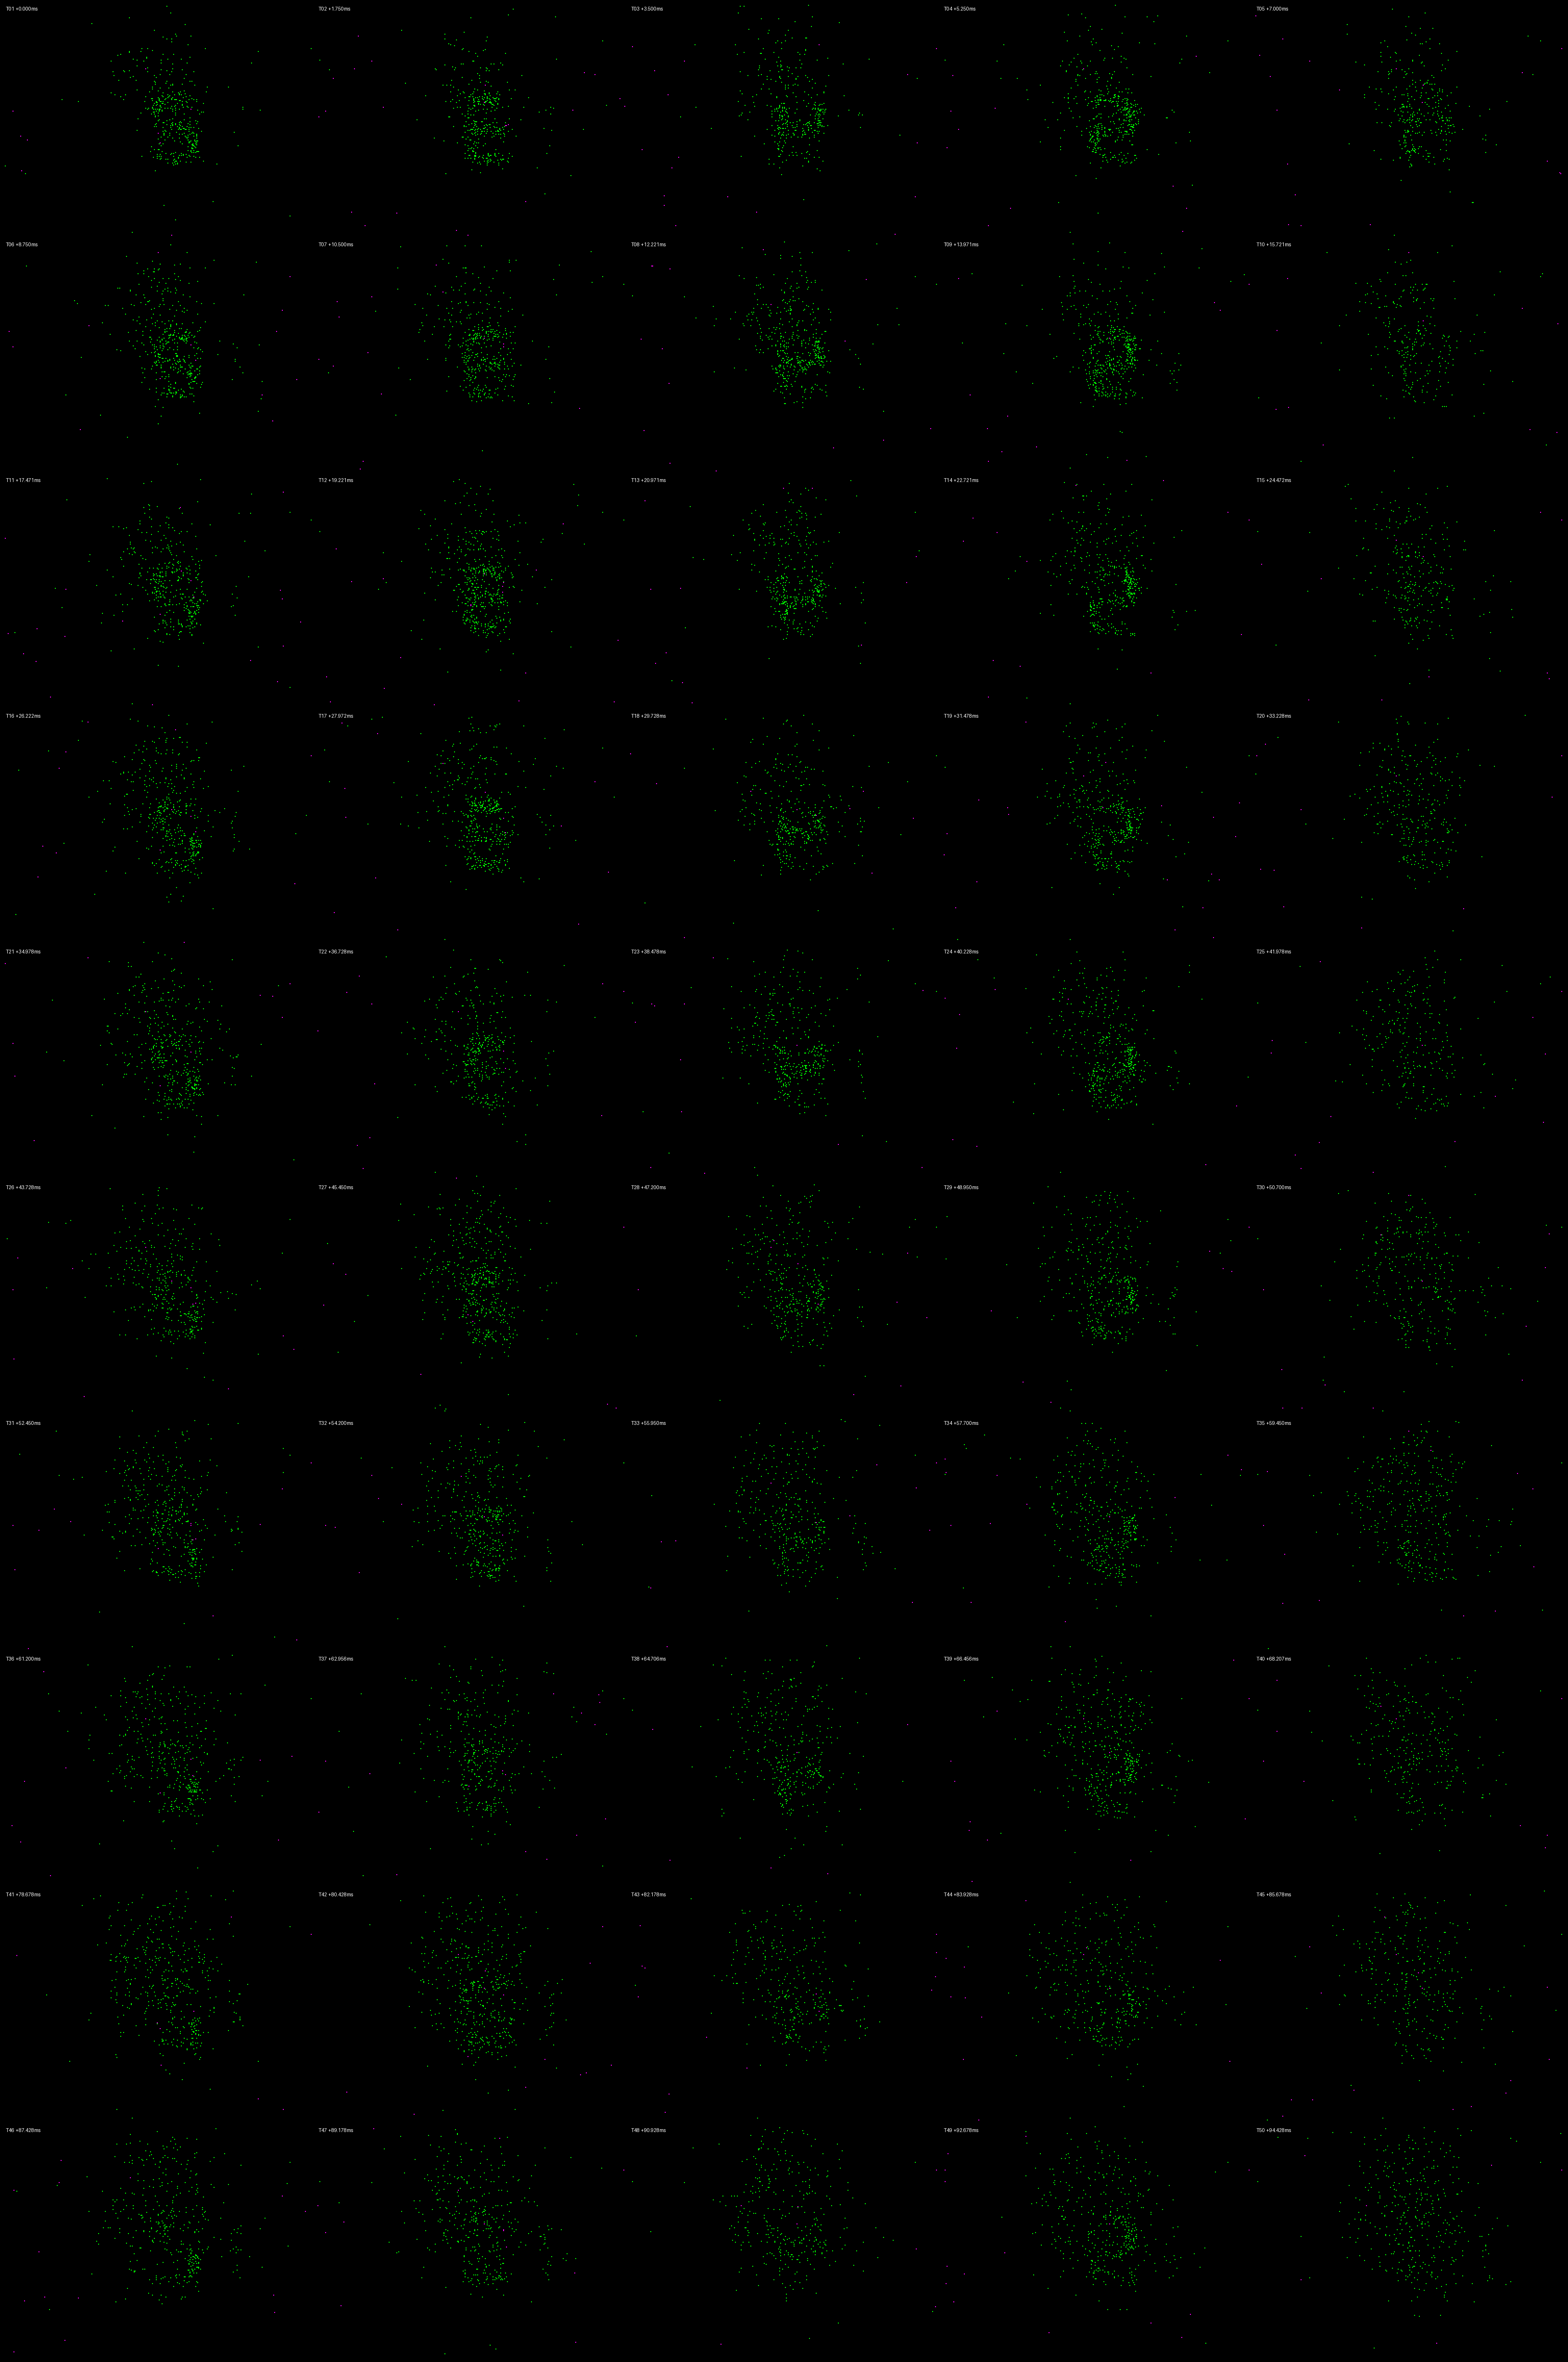

In [15]:
DISPLAY_TONE_CURVE = "gamma"  # "linear", "log", or "gamma".
DISPLAY_GAMMA = 0.5
DISPLAY_PERCENTILE = None  # None uses the full nonzero max. Use 99.5 to intentionally clip outliers.

def _scale_label(percentile=DISPLAY_PERCENTILE):
    if percentile is None:
        return "maxscale"
    return f"p{str(percentile).replace('.', 'p')}"

def _scale_to_uint8(values, vmax=None, percentile=DISPLAY_PERCENTILE, tone_curve=DISPLAY_TONE_CURVE, gamma=DISPLAY_GAMMA):
    arr = np.asarray(values, dtype=np.float32)
    if vmax is None:
        nonzero = arr[arr > 0]
        if not nonzero.size:
            vmax = 1.0
        elif percentile is None:
            vmax = float(nonzero.max())
        else:
            vmax = float(np.percentile(nonzero, percentile))
    vmax = max(float(vmax), 1e-6)
    if tone_curve == "linear":
        scaled = arr / vmax
    elif tone_curve == "log":
        scaled = np.log1p(arr) / np.log1p(vmax)
    elif tone_curve == "gamma":
        scaled = np.power(np.clip(arr / vmax, 0, None), gamma)
    else:
        raise ValueError(f"unknown tone curve: {tone_curve}")
    return np.rint(np.clip(scaled * 255.0, 0, 255)).astype(np.uint8), vmax

def render_frame(frame, mode="positive", vmax=None):
    frame = np.asarray(frame, dtype=np.float32)
    if mode == "positive":
        image, used_vmax = _scale_to_uint8(np.maximum(frame, 0), vmax=vmax)
        return Image.fromarray(image), used_vmax
    if mode == "absolute":
        image, used_vmax = _scale_to_uint8(np.abs(frame), vmax=vmax)
        return Image.fromarray(image), used_vmax
    if mode == "signed_rgb":
        pos, used_vmax = _scale_to_uint8(np.maximum(frame, 0), vmax=vmax)
        neg, _ = _scale_to_uint8(np.maximum(-frame, 0), vmax=used_vmax)
        rgb = np.zeros((frame.shape[0], frame.shape[1], 3), dtype=np.uint8)
        rgb[..., 1] = pos
        rgb[..., 0] = neg
        rgb[..., 2] = neg
        return Image.fromarray(rgb), used_vmax
    raise ValueError(mode)

DISPLAY_FLIP_X = False  # Primary notebook display orientation. True mirrors each tile for easier digit reading.
DISPLAY_SAVE_ALTERNATE_FLIP_X = True

def _orientation_suffix(flip_x):
    return "_flip_x" if flip_x else ""

def _orientation_variants():
    variants = [(DISPLAY_FLIP_X, _orientation_suffix(DISPLAY_FLIP_X))]
    alternate = not DISPLAY_FLIP_X
    if DISPLAY_SAVE_ALTERNATE_FLIP_X:
        variants.append((alternate, _orientation_suffix(alternate)))
    return variants

def make_contact(frames, *, mode="positive", cols=None, labels=None, scale=2, pad=10, flip_x=False):
    frames = np.asarray(frames)
    if cols is None:
        cols = cycle_len
    rows = int(math.ceil(len(frames) / cols))
    h, w = frames.shape[1:3]
    if mode == "positive":
        _, vmax = _scale_to_uint8(np.maximum(frames, 0))
    elif mode == "absolute":
        _, vmax = _scale_to_uint8(np.abs(frames))
    else:
        _, vmax = _scale_to_uint8(np.maximum(np.abs(frames), 0))
    tile_w, tile_h = w * scale, h * scale
    sheet_mode = "RGB" if mode == "signed_rgb" else "L"
    bg = (0, 0, 0) if sheet_mode == "RGB" else 0
    sheet = Image.new(sheet_mode, (cols * tile_w + (cols + 1) * pad, rows * tile_h + (rows + 1) * pad), bg)
    draw = ImageDraw.Draw(sheet)
    for i, frame in enumerate(frames):
        row, col = divmod(i, cols)
        image, _ = render_frame(frame, mode=mode, vmax=vmax)
        if flip_x:
            image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
        image = image.resize((tile_w, tile_h), Image.Resampling.NEAREST)
        x = pad + col * (tile_w + pad)
        y = pad + row * (tile_h + pad)
        sheet.paste(image, (x, y))
        if labels:
            text = labels[i]
            bbox = draw.textbbox((0, 0), text)
            label_w = min(tile_w, max(40, bbox[2] - bbox[0] + 6))
            label_h = min(tile_h, max(15, bbox[3] - bbox[1] + 5))
            if sheet_mode == "RGB":
                draw.rectangle((x, y, x + label_w, y + label_h), fill=(0, 0, 0))
                draw.text((x + 2, y + 2), text, fill=(255, 255, 255))
            else:
                draw.rectangle((x, y, x + label_w, y + label_h), fill=0)
                draw.text((x + 2, y + 2), text, fill=255)
    return sheet

ordered_accumulated = accumulated[trigger_order]
trigger_labels = []
t0 = int(ordered_trigger_ts[0]) if len(ordered_trigger_ts) else 0
for rank, original_index in enumerate(trigger_order, start=1):
    delta_ms = (int(trigger_ts[original_index]) - t0) / 1000.0
    trigger_labels.append(f"T{rank:02d} +{delta_ms:.3f}ms")

print("Timestamp order from triggers.csv:")
for row_start in range(0, len(trigger_labels), cycle_len):
    print("  " + " | ".join(trigger_labels[row_start:row_start + cycle_len]))

orientation_suffix = _orientation_suffix(DISPLAY_FLIP_X)
tone_suffix = f"_{DISPLAY_TONE_CURVE}_{_scale_label()}"
for flip_x, suffix in _orientation_variants():
    for mode in ["positive", "absolute", "signed_rgb"]:
        sheet = make_contact(ordered_accumulated, mode=mode, labels=trigger_labels, scale=2, flip_x=flip_x)
        path = OUT_DIR / f"timestamp_ordered_{mode}_black_background{tone_suffix}{suffix}.png"
        sheet.save(path)
        print(path)
        if display is not None and flip_x == DISPLAY_FLIP_X:
            display(sheet)


## Event depth check

This shows whether tone curves have enough count depth to work with. If percentile scaling reports `vmax=1`, every nonzero pixel will render white regardless of the selected curve.


In [ ]:
magnitudes = np.abs(ordered_accumulated.astype(np.float32))
nonzero = magnitudes[magnitudes > 0]
print(f"nonzero pixels: {nonzero.size} / {magnitudes.size} ({(nonzero.size / magnitudes.size * 100) if magnitudes.size else 0:.4f}%)")
if nonzero.size:
    values, counts = np.unique(nonzero, return_counts=True)
    print("nonzero magnitude histogram:")
    for value, count in zip(values, counts):
        print(f"  {value:g}: {count} ({count / nonzero.size * 100:.3f}%)")
    for percentile in [99.0, 99.5, 100.0]:
        vmax = float(np.percentile(nonzero, percentile))
        print(f"vmax at p{percentile:g}: {vmax:g}")
    vmax = float(nonzero.max())
    print("tone mapping with max-scale:")
    for value in range(1, int(math.ceil(vmax)) + 1):
        linear = round(value / vmax * 255)
        log = round(np.log1p(value) / np.log1p(vmax) * 255)
        gamma = round((value / vmax) ** DISPLAY_GAMMA * 255)
        print(f"  count {value}: linear={linear}, log={log}, gamma={gamma}")


## Repeat-summed slot views

These sum timestamp-ordered frames by trigger position: slot 1 uses frames `1,6,11,...`, slot 2 uses `2,7,12,...`, and so on. This should make the ten repeats per expected number much easier to inspect without changing the raw data.


In [ ]:
def _expected_number_for_slot(slot):
    return number_sequence[slot] if slot < len(number_sequence) else slot + 1

def sum_by_slot(frames, cycle_len):
    slot_frames = []
    labels = []
    for slot in range(cycle_len):
        indices = list(range(slot, len(frames), cycle_len))
        if not indices:
            continue
        selected = frames[indices]
        summed = selected.sum(axis=0)
        slot_frames.append(summed)
        labels.append(f"slot {slot + 1} exp {_expected_number_for_slot(slot)} n={len(indices)}")
        positive_sums = [float(np.maximum(frame, 0).sum()) for frame in selected]
        print(
            f"slot {slot + 1} expected {_expected_number_for_slot(slot)}: "
            f"trigger_ranks={[i + 1 for i in indices]}, "
            f"positive_total={sum(positive_sums):.0f}, "
            f"per_trigger_min_mean_max={min(positive_sums):.0f}/{statistics.mean(positive_sums):.1f}/{max(positive_sums):.0f}"
        )
    return np.stack(slot_frames), labels

slot_sums, slot_sum_labels = sum_by_slot(ordered_accumulated, cycle_len)
slot_mag = np.abs(slot_sums.astype(np.float32))
slot_nonzero = slot_mag[slot_mag > 0]
if slot_nonzero.size:
    print(f"slot-summed nonzero max: {float(slot_nonzero.max()):g}")
    print(f"slot-summed p99.5: {float(np.percentile(slot_nonzero, 99.5)):g}")

for flip_x, suffix in _orientation_variants():
    for mode in ["positive", "absolute", "signed_rgb"]:
        sheet = make_contact(slot_sums, mode=mode, cols=len(slot_sums), labels=slot_sum_labels, scale=3, flip_x=flip_x)
        path = OUT_DIR / f"timestamp_ordered_slot_sums_{mode}_black_background{tone_suffix}{suffix}.png"
        sheet.save(path)
        print(path)
        if display is not None and flip_x == DISPLAY_FLIP_X:
            display(sheet)

cycle_sums = []
cycle_labels = []
for start in range(0, len(ordered_accumulated), cycle_len):
    selected = ordered_accumulated[start:start + cycle_len]
    if len(selected) != cycle_len:
        continue
    cycle_sums.append(selected.sum(axis=0))
    cycle_labels.append(f"cycle {len(cycle_labels) + 1}")

if cycle_sums:
    cycle_sums = np.stack(cycle_sums)
    for flip_x, suffix in _orientation_variants():
        sheet = make_contact(cycle_sums, mode="positive", cols=min(5, len(cycle_sums)), labels=cycle_labels, scale=2, flip_x=flip_x)
        path = OUT_DIR / f"timestamp_ordered_cycle_sums_positive_black_background{tone_suffix}{suffix}.png"
        sheet.save(path)
        print(path)
        if display is not None and flip_x == DISPLAY_FLIP_X:
            display(sheet)


## Slot consistency check

If the selected frames are ordered correctly, all slot-1 images should look more like each other than like slot-2, slot-3, etc. This is a quick numerical check for jumbling.

mean same-slot correlation:      0.0473
mean different-slot correlation: 0.0323
slot 1 number 1: frames=[1, 6, 11, 16, 21, 26, 31, 36, 41, 46], positive_sums=[402.0, 446.0, 408.0, 451.0, 449.0, 386.0, 428.0, 420.0, 438.0, 400.0]
slot 2 number 2: frames=[2, 7, 12, 17, 22, 27, 32, 37, 42, 47], positive_sums=[379.0, 416.0, 487.0, 473.0, 392.0, 503.0, 434.0, 378.0, 489.0, 393.0]
slot 3 number 3: frames=[3, 8, 13, 18, 23, 28, 33, 38, 43, 48], positive_sums=[375.0, 459.0, 405.0, 383.0, 410.0, 382.0, 372.0, 377.0, 333.0, 339.0]
slot 4 number 4: frames=[4, 9, 14, 19, 24, 29, 34, 39, 44, 49], positive_sums=[449.0, 474.0, 425.0, 420.0, 469.0, 426.0, 418.0, 462.0, 389.0, 426.0]
slot 5 number 5: frames=[5, 10, 15, 20, 25, 30, 35, 40, 45, 50], positive_sums=[336.0, 265.0, 289.0, 306.0, 273.0, 325.0, 381.0, 313.0, 316.0, 393.0]


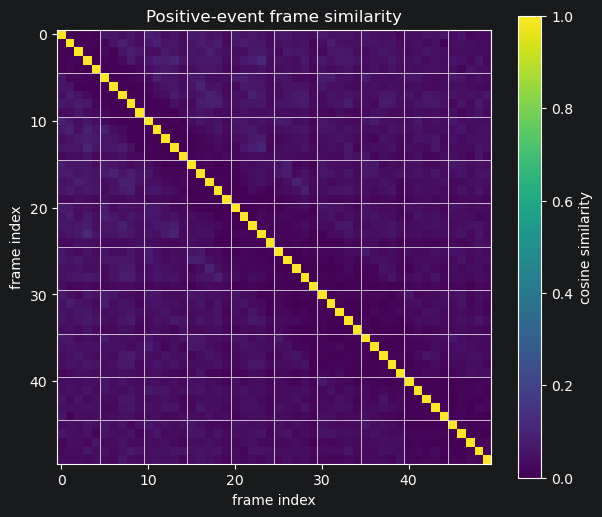

In [16]:
features = np.maximum(ordered_accumulated, 0).reshape(ordered_accumulated.shape[0], -1)
norm = np.linalg.norm(features, axis=1, keepdims=True)
features_norm = np.divide(features, norm, out=np.zeros_like(features), where=norm > 0)
corr = features_norm @ features_norm.T

same_slot = []
different_slot = []
for i in range(len(corr)):
    for j in range(i + 1, len(corr)):
        if i % cycle_len == j % cycle_len:
            same_slot.append(float(corr[i, j]))
        else:
            different_slot.append(float(corr[i, j]))

print(f"mean same-slot correlation:      {statistics.mean(same_slot):.4f}")
print(f"mean different-slot correlation: {statistics.mean(different_slot):.4f}")

for slot in range(cycle_len):
    indices = list(range(slot, ordered_accumulated.shape[0], cycle_len))
    sums = [float(np.maximum(ordered_accumulated[i], 0).sum()) for i in indices]
    print(f"slot {slot + 1} number {number_sequence[slot] if slot < len(number_sequence) else slot + 1}: frames={[i + 1 for i in indices]}, positive_sums={[round(v, 1) for v in sums]}")

if plt is not None:
    plt.figure(figsize=(7, 6))
    plt.imshow(corr, vmin=0, vmax=1, cmap="viridis")
    plt.colorbar(label="cosine similarity")
    plt.title("Positive-event frame similarity")
    plt.xlabel("frame index")
    plt.ylabel("frame index")
    for boundary in range(cycle_len, ordered_accumulated.shape[0], cycle_len):
        plt.axhline(boundary - 0.5, color="white", linewidth=0.5)
        plt.axvline(boundary - 0.5, color="white", linewidth=0.5)
    plt.show()

## Re-accumulate selected triggers with timing offsets

This uses `filtered_events.npz` plus the selected `triggers.csv` timestamps. It cannot recover cycles that were not selected by `strongest`, but it can test whether each selected window should start earlier or later than the trigger timestamp.

In [17]:
events_t = events_npz["t"].astype(np.int64)
events_x = events_npz["x"].astype(np.int64)
events_y = events_npz["y"].astype(np.int64)
events_p = events_npz["p"].astype(bool)

def accumulate_selected(offset_us=0, window_us=window_us, polarity_mode="positive"):
    width, height = int(resolution[0]), int(resolution[1])
    frames = np.zeros((len(trigger_ts), height, width), dtype=np.float32)
    if polarity_mode == "positive":
        values = events_p.astype(np.float32)
        valid_polarity = events_p
    elif polarity_mode == "signed":
        values = np.where(events_p, 1.0, -1.0).astype(np.float32)
        valid_polarity = np.ones_like(events_p, dtype=bool)
    elif polarity_mode == "ignore":
        values = np.ones_like(events_p, dtype=np.float32)
        valid_polarity = np.ones_like(events_p, dtype=bool)
    else:
        raise ValueError(polarity_mode)
    valid_xy = (events_x >= 0) & (events_x < width) & (events_y >= 0) & (events_y < height) & valid_polarity
    t = events_t[valid_xy]
    x = events_x[valid_xy]
    y = events_y[valid_xy]
    v = values[valid_xy]
    for i, trigger_time in enumerate(trigger_ts):
        start = int(trigger_time) + int(offset_us)
        end = start + int(window_us)
        left = np.searchsorted(t, start, side="left")
        right = np.searchsorted(t, end, side="left")
        if left < right:
            np.add.at(frames[i], (y[left:right], x[left:right]), v[left:right])
    return frames

offsets = [-1000, -500, -250, 0, 250, 500, 1000]
print(f"window_us={window_us}")
for offset in offsets:
    frames = accumulate_selected(offset_us=offset, polarity_mode="positive")
    counts = [int(np.maximum(frame, 0).sum()) for frame in frames]
    grouped = [counts[i:i + cycle_len] for i in range(0, len(counts), cycle_len)]
    total = sum(counts)
    per_frame_nonzero = int(sum(np.count_nonzero(frame) for frame in frames))
    print(f"offset {offset:+5d} us: total_positive_events={total:6d}, nonzero_pixels={per_frame_nonzero:6d}, first3_groups={grouped[:3]}")

window_us=1500
offset -1000 us: total_positive_events= 20133, nonzero_pixels= 20068, first3_groups=[[312, 409, 394, 403, 477], [345, 448, 459, 446, 441], [270, 470, 472, 363, 406]]
offset  -500 us: total_positive_events= 19633, nonzero_pixels= 19577, first3_groups=[[326, 352, 433, 445, 374], [368, 498, 394, 378, 392], [347, 422, 362, 445, 385]]
offset  -250 us: total_positive_events= 19487, nonzero_pixels= 19429, first3_groups=[[387, 345, 382, 455, 364], [368, 442, 448, 403, 305], [392, 471, 354, 407, 369]]
offset    +0 us: total_positive_events= 20081, nonzero_pixels= 20020, first3_groups=[[404, 381, 379, 453, 339], [448, 417, 460, 476, 267], [409, 491, 408, 428, 292]]
offset  +250 us: total_positive_events= 20914, nonzero_pixels= 20845, first3_groups=[[431, 418, 432, 486, 317], [505, 447, 434, 514, 293], [433, 473, 425, 505, 290]]
offset  +500 us: total_positive_events= 20418, nonzero_pixels= 20358, first3_groups=[[408, 394, 427, 487, 303], [467, 460, 414, 455, 292], [460, 428, 367, 

C:\dev\dmdcontrol\runs\camera\laser_selected_cycle_40px_dot123-sync-check\analysis_outputs\timestamp_ordered_reaccumulated_positive_offset_+0us_gamma.png


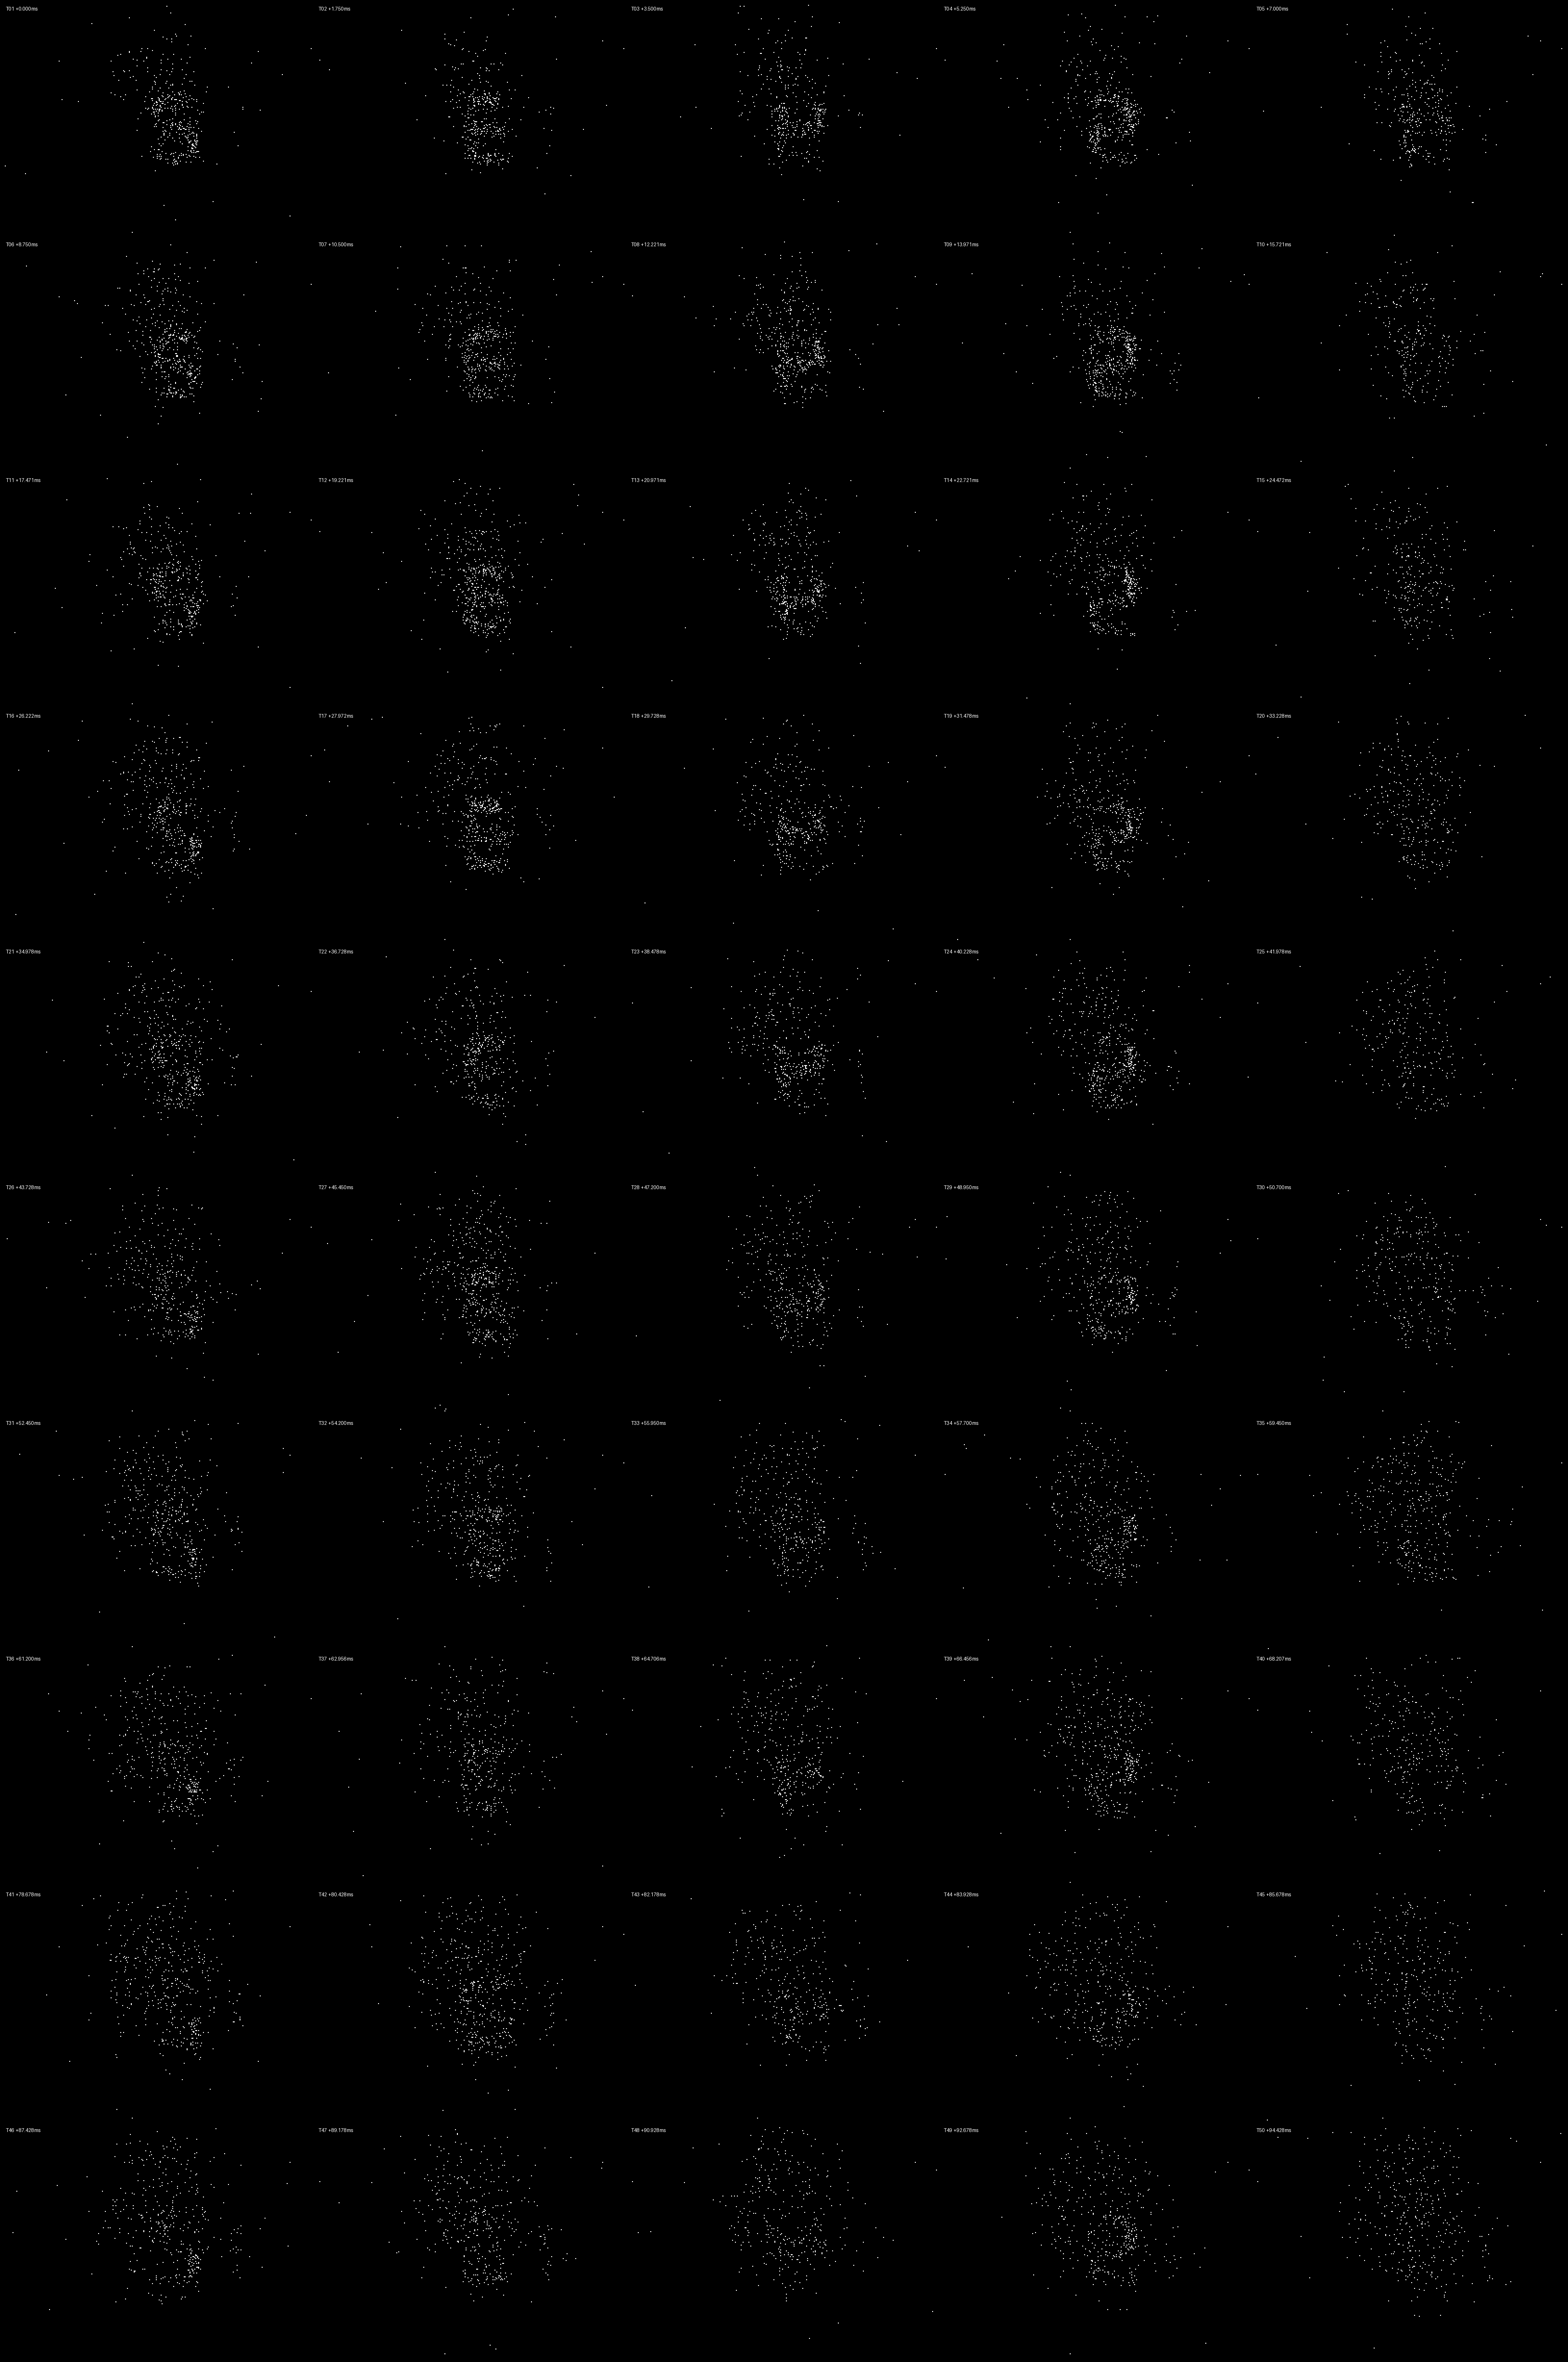

In [18]:
CHOSEN_OFFSET_US = 0
frames = accumulate_selected(offset_us=CHOSEN_OFFSET_US, polarity_mode="positive")
for flip_x, suffix in _orientation_variants():
    sheet = make_contact(frames[trigger_order], mode="positive", labels=trigger_labels, scale=2, flip_x=flip_x)
    path = OUT_DIR / f"timestamp_ordered_reaccumulated_positive_offset_{CHOSEN_OFFSET_US:+d}us{tone_suffix}{suffix}.png"
    sheet.save(path)
    print(path)
    if display is not None and flip_x == DISPLAY_FLIP_X:
        display(sheet)


## Interpretation for this run

- New runs select the first complete cycles after pre-capture trigger flushing. If an older run used legacy strongest-cycle selection, use this notebook's trigger-gap table before assuming the rows are adjacent physical cycles.
- The saved PNG gray/white background is a rendering artifact from signed min/max normalization. Trust `accumulated.npy` and the black-background outputs in `analysis_outputs` for visual inspection.
- For a consecutive `1,2,3,4,5` x10 capture after optics are stable, rerun with `--accumulation-cycles 10`.